## Handling Imbalanced Dataset

### 1. Up Sampling
### 2. Down Sampling

In [22]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import resample
np.random.seed(10)

In [23]:
n_samples = 1000
class_0_ratio = 0.9
n_class_0 = int(n_samples * class_0_ratio)
n_class_1 = n_samples - n_class_0
print(f'Class 0 samples: {n_class_0}, Class 1 samples: {n_class_1}')

Class 0 samples: 900, Class 1 samples: 100


## Up Sampling
#### It is a technique where we increase the number of samples in the minority class by replicating them. This can be done by randomly sampling with replacement from the minority class until we have the same number of samples as the majority class.
#### 1. Replication : raplicate the original data
#### 2. Smote : interpolate the 2 nearby points

### 1. Replication

In [24]:
class_0 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature_2': np.random.normal(loc=0, scale=1, size=n_class_0),
    'target': [0] * n_class_0
})

class_1 = pd.DataFrame({
    'feature_1': np.random.normal(loc=2, scale=1, size=n_class_1),
    'feature_2': np.random.normal(loc=2, scale=1, size=n_class_1),
    'target': [1] * n_class_1
})

In [25]:
df=pd.concat([class_0,class_1],axis=0).reset_index(drop=True)

In [26]:
df

,feature_1,feature_2,target
0,1.331587,-0.465984,0
1,0.715279,0.067767,0
2,-1.545400,-0.224467,0
3,-0.008384,0.071738,0
4,0.621336,-0.116762,0
...,...,...,...
995,2.058657,2.633243,1
996,1.045674,3.152625,1
997,2.794839,2.372233,1
998,2.709196,2.612246,1


In [27]:
df.shape

(1000, 3)

<Axes: xlabel='feature_1', ylabel='feature_2'>

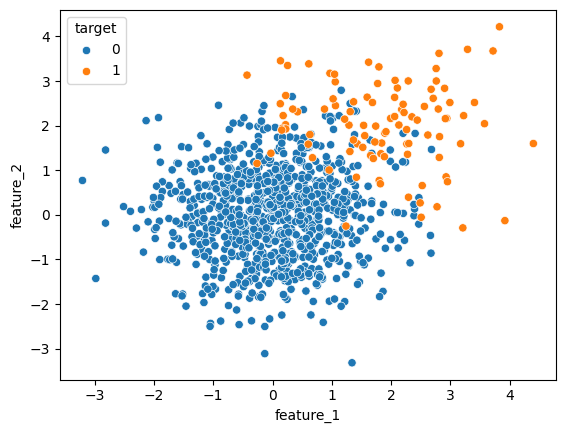

In [28]:
## Gaussian distribution of features
sns.scatterplot(data=df, x='feature_1', y='feature_2', hue='target')

In [29]:
df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [30]:
df_minority = df[df['target'] == 1]
df_majority = df[df['target'] == 0]

In [31]:
df_minority_upsampled = resample(df_minority, replace=True, n_samples=len(df_majority), random_state=10)

In [32]:
print(f'Original minority class samples: {len(df_minority)}, Upsampled minority class samples: {len(df_minority_upsampled)}')

Original minority class samples: 100, Upsampled minority class samples: 900


In [33]:
df_upsampled=pd.concat([df_majority,df_minority_upsampled])
df_upsampled.head(10)

,feature_1,feature_2,target
0,1.331587,-0.465984,0
1,0.715279,0.067767,0
2,-1.545400,-0.224467,0
3,-0.008384,0.071738,0
4,0.621336,-0.116762,0
5,-0.720086,-0.469859,0
6,0.265512,-1.109208,0
7,0.108549,-1.238459,0
8,0.004291,0.341388,0
9,-0.174600,-0.036968,0


### 2. Smote Technique

In [ ]:
%pip install imblearn

In [35]:
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE

In [36]:
X,y=make_classification(n_samples=1000,n_redundant=0,n_features=2,n_clusters_per_class=1,
                   weights=[0.90],random_state=12)

In [37]:
df1=pd.DataFrame(X,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
final_df=pd.concat([df1,df2],axis=1)
final_df.head()

,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


In [38]:
final_df.value_counts('target')

target
0    900
1    100
Name: count, dtype: int64

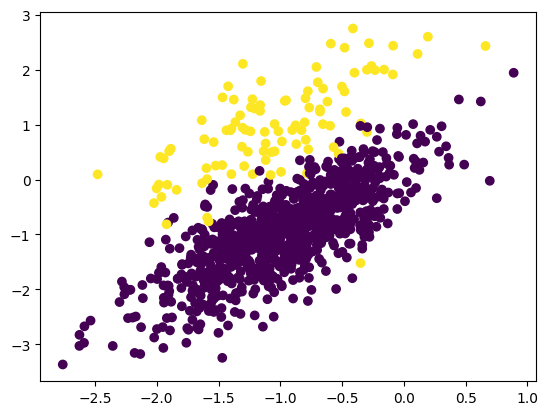

In [39]:
plt.scatter(final_df['f1'],final_df['f2'],c=final_df['target'])

In [41]:
smote=SMOTE(random_state=12)
X_resampled,Y_resampled=smote.fit_resample(X,y)

In [42]:
X_resampled.shape

(1800, 2)

In [43]:
Y_resampled.shape

(1800,)

In [44]:
len(Y_resampled[Y_resampled==0]),len(Y_resampled[Y_resampled==1])

(900, 900)

In [45]:
df1=pd.DataFrame(X_resampled,columns=['f1','f2'])
df2=pd.DataFrame(Y_resampled,columns=['target'])
oversample_df=pd.concat([df1,df2],axis=1)

Text(0.5, 1.0, 'After SMOTE')

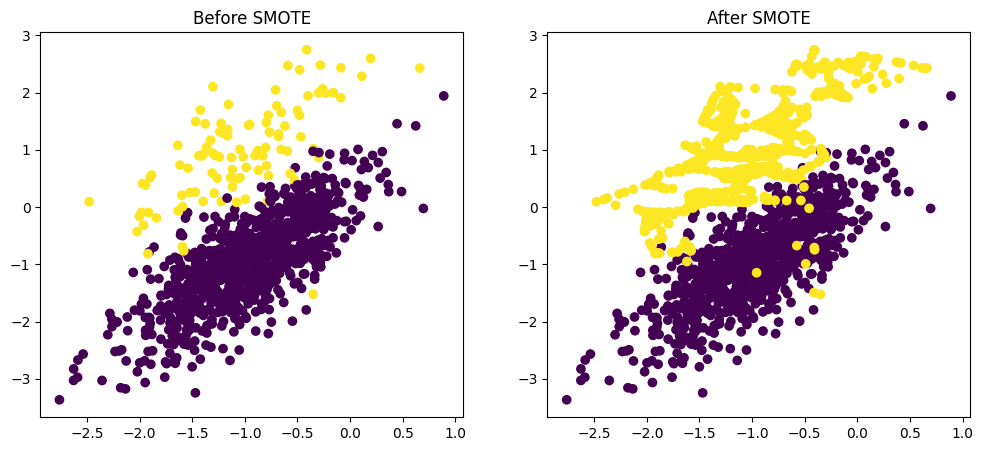

In [50]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(final_df['f1'], final_df['f2'], c=final_df['target'])
plt.title("Before SMOTE")
plt.subplot(1,2,2)
plt.scatter(oversample_df['f1'], oversample_df['f2'], c=oversample_df['target'])
plt.title("After SMOTE")

## Down Sampling
#### Randomly select samples from the majority class to match the number of samples in the minority class. This can be done using the `resample` function from `sklearn.utils`.

In [52]:
df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [53]:
df_majority=df[df['target']==0]
df_minority=df[df['target']==1]

In [54]:
df_majority_downsampled = resample(df_majority, replace=False, n_samples=len(df_minority), random_state=10)

In [55]:
df_majority_downsampled.shape

(100, 3)

In [56]:
df_majority_downsampled['target'].value_counts()

target
0    100
Name: count, dtype: int64

In [57]:
df_downsampled=pd.concat([df_majority_downsampled,df_minority])
df_downsampled['target'].value_counts()

target
0    100
1    100
Name: count, dtype: int64